In [1]:
print("hi")

hi


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline 

Text(0, 0.5, 'Y dataset')

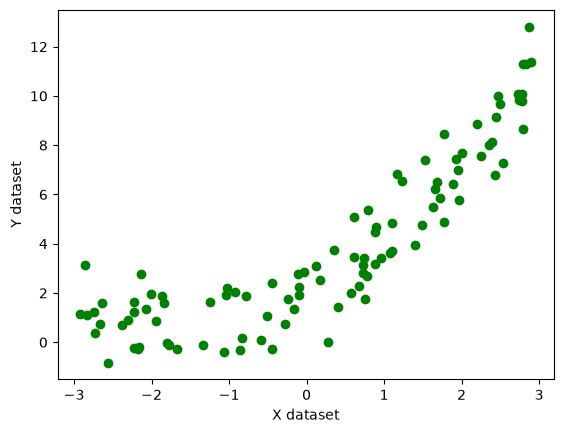

In [3]:
X = 6 * np.random.rand(100, 1) - 3
y =0.5 * X**2 + 1.5*X + 2 + np.random.randn(100, 1)
# quadratic equation used- y=0.5x^2+1.5x+2+outliers
plt.scatter(X,y,color='g')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
## Lets implement Simple Linear Regression
from sklearn.linear_model import LinearRegression
regression_1=LinearRegression()

In [9]:
regression_1.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[1.7]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[3.55]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[16.11]


In [10]:
from sklearn.metrics import r2_score
score=r2_score(y_test,regression_1.predict(X_test))
print(score)

0.5563442674187898


Text(0, 0.5, 'Y')

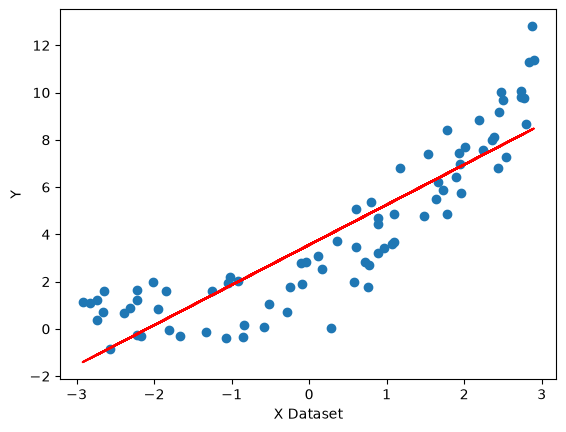

In [11]:
## Lets visualize this model
plt.plot(X_train,regression_1.predict(X_train),color='r')
plt.scatter(X_train,y_train)
plt.xlabel("X Dataset")
plt.ylabel("Y")

In [12]:
#LEts apply polynomial transformation
from sklearn.preprocessing import PolynomialFeatures

In [13]:
poly=PolynomialFeatures(degree=2,include_bias=True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [14]:
X_train_poly

array([[ 1.00000000e+00,  7.58252415e-01,  5.74946725e-01],
       [ 1.00000000e+00,  1.69992938e-01,  2.88975988e-02],
       [ 1.00000000e+00, -2.73459229e+00,  7.47799499e+00],
       [ 1.00000000e+00,  2.00874757e+00,  4.03506680e+00],
       [ 1.00000000e+00,  2.87333778e+00,  8.25607003e+00],
       [ 1.00000000e+00, -2.22032992e+00,  4.92986496e+00],
       [ 1.00000000e+00,  2.89593749e+00,  8.38645393e+00],
       [ 1.00000000e+00, -2.17194843e+00,  4.71736000e+00],
       [ 1.00000000e+00, -2.56574253e+00,  6.58303475e+00],
       [ 1.00000000e+00, -2.22609986e+00,  4.95552057e+00],
       [ 1.00000000e+00,  1.72387194e+00,  2.97173448e+00],
       [ 1.00000000e+00,  2.53586889e+00,  6.43063103e+00],
       [ 1.00000000e+00,  8.82530812e-01,  7.78860635e-01],
       [ 1.00000000e+00,  2.35435334e+00,  5.54297963e+00],
       [ 1.00000000e+00,  2.73489413e+00,  7.47964590e+00],
       [ 1.00000000e+00,  1.16708377e+00,  1.36208453e+00],
       [ 1.00000000e+00,  2.43209689e+00

In [15]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score=r2_score(y_test,y_pred)
print(score)

0.8564315309635357


In [16]:
print(regression.coef_)

[[0.         1.65518869 0.45949744]]


In [17]:
print(regression.intercept_)

[2.03480707]


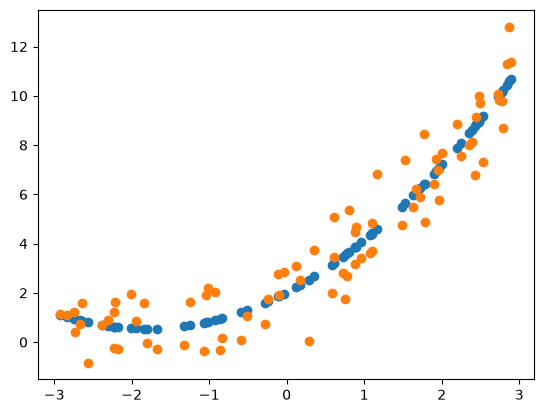

In [18]:
plt.scatter(X_train,regression.predict(X_train_poly))
plt.scatter(X_train,y_train)

In [19]:
poly=PolynomialFeatures(degree=3,include_bias=True)
X_train_poly=poly.fit_transform(X_train)
X_test_poly=poly.transform(X_test)

In [20]:
X_train_poly

array([[ 1.00000000e+00,  7.58252415e-01,  5.74946725e-01,
         4.35954743e-01],
       [ 1.00000000e+00,  1.69992938e-01,  2.88975988e-02,
         4.91238771e-03],
       [ 1.00000000e+00, -2.73459229e+00,  7.47799499e+00,
        -2.04492675e+01],
       [ 1.00000000e+00,  2.00874757e+00,  4.03506680e+00,
         8.10543063e+00],
       [ 1.00000000e+00,  2.87333778e+00,  8.25607003e+00,
         2.37224780e+01],
       [ 1.00000000e+00, -2.22032992e+00,  4.92986496e+00,
        -1.09459267e+01],
       [ 1.00000000e+00,  2.89593749e+00,  8.38645393e+00,
         2.42866463e+01],
       [ 1.00000000e+00, -2.17194843e+00,  4.71736000e+00,
        -1.02458627e+01],
       [ 1.00000000e+00, -2.56574253e+00,  6.58303475e+00,
        -1.68903723e+01],
       [ 1.00000000e+00, -2.22609986e+00,  4.95552057e+00,
        -1.10314836e+01],
       [ 1.00000000e+00,  1.72387194e+00,  2.97173448e+00,
         5.12288970e+00],
       [ 1.00000000e+00,  2.53586889e+00,  6.43063103e+00,
      

In [21]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score=r2_score(y_test,y_pred)
print(score)

0.8562689529938445


In [22]:
#3 Prediction of new data set
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

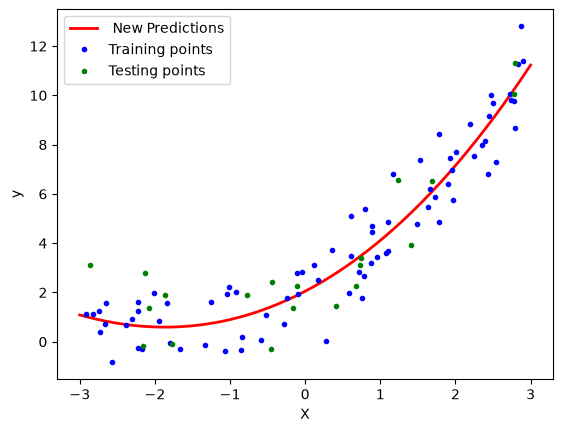

In [23]:
y_new = regression.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth=2, label=" New Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## Pipeline Concepts

In [24]:
from sklearn.pipeline import Pipeline

In [25]:
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    
    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
    ])
    poly_regression.fit(X_train,y_train) ## ploynomial and fit of linear reression
    y_pred_new=poly_regression.predict(X_new)
    #plotting prediction line
    plt.plot(X_new, y_pred_new,'r', label="Degree " + str(degree), linewidth=2)
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4, 0, 10])
    plt.show()

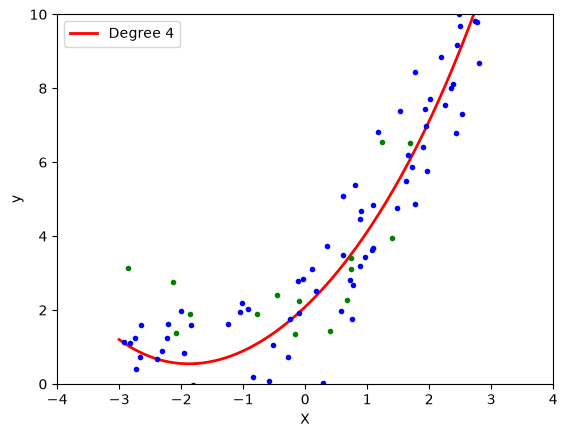

In [29]:
poly_regression(4)